In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import numpy as np
import sklearn

In [3]:
# import the dataset
with open('../config.yaml', 'r') as file:
    config = yaml.safe_load(file)
df = pd.read_csv(config["input_data"]["file_1"])

In [4]:
# check quickly data content
print(df.shape)
print(df.isnull().sum())
print(df.dtypes)
print(df.select_dtypes("str").nunique().sort_values(ascending=False))

(2111, 17)
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64
Gender                                str
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight        str
FAVC                                  str
FCVC                              float64
NCP                               float64
CAEC                        

In [5]:
# drop duplicates
df.drop_duplicates(inplace=True)

In [7]:
df.shape

(2087, 17)

In [8]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,24.353090,1.702674,86.858730,2.421466,2.701179,2.004749,1.012812,0.663035
std,6.368801,0.093186,26.190847,0.534737,0.764614,0.608284,0.853475,0.608153
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.915937,1.630178,66.000000,2.000000,2.697467,1.590922,0.124505,0.000000
50%,22.847618,1.701584,83.101100,2.396265,3.000000,2.000000,1.000000,0.630866
75%,26.000000,1.769491,108.015907,3.000000,3.000000,2.466193,1.678102,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [9]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [21]:
### Column  Meaning 

#Age      Age
#Height  Height
#Weight  Weight
#Gender  Gender
#FCVC   Vegetable consumption frequency
#NCP    Number of main meals/day
#CH2O   Daily water intake
#FAF    Physical activity frequency
#TUE    Daily screen time
#Family history of overweight
#FAVC   Frequent high-calorie food intake
#CAEC   Snacking between meals
#SMOKE  Smoker
#SCC    Monitors Calories daily
#FAF    How often practices physical activity
#CALC   Alcohol consumption frequency
#MTRANS Main transportation method

#NObeyesdadObesity level (target)

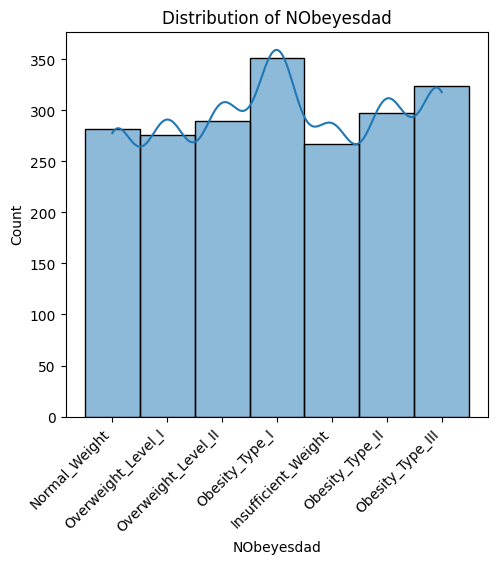

In [22]:
# check the distribution of the target variable NObeyesdad
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(x="NObeyesdad", data=df, kde=True)
plt.title("Distribution of NObeyesdad")
plt.xticks(rotation=45, ha="right") 
plt.show()

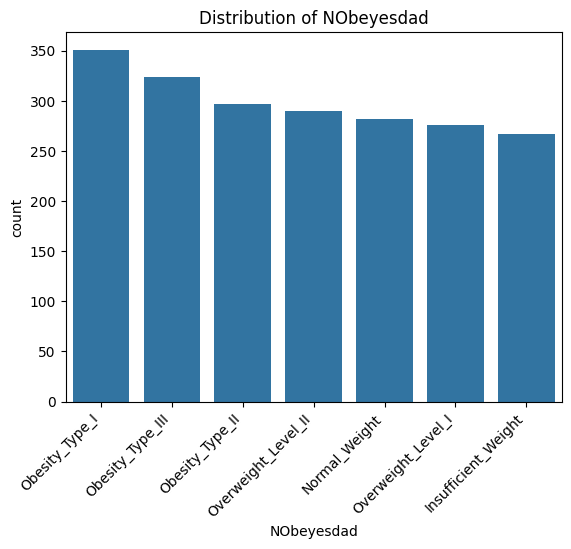

In [23]:
sns.countplot(x="NObeyesdad", data=df, order=df["NObeyesdad"].value_counts().index)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of NObeyesdad")
plt.show()

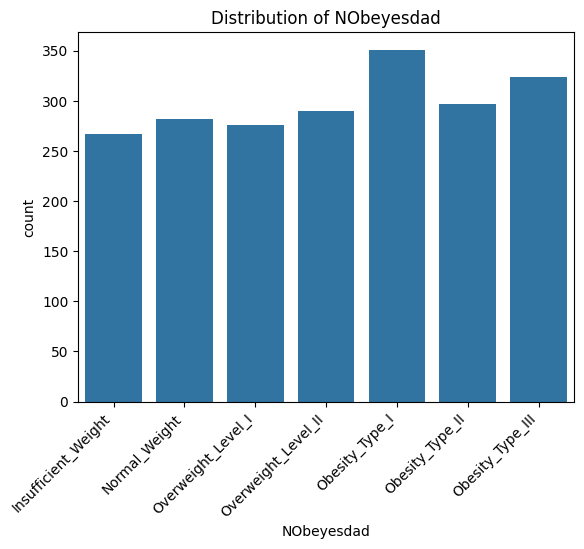

In [21]:
# now let's order the previous plot from inssuffucunt weight to obesity type III
order = ["Insufficient_Weight", "Normal_Weight", "Overweight_Level_I", "Overweight_Level_II", "Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"]
sns.countplot(x="NObeyesdad", data=df, order=order)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of NObeyesdad")
plt.show()


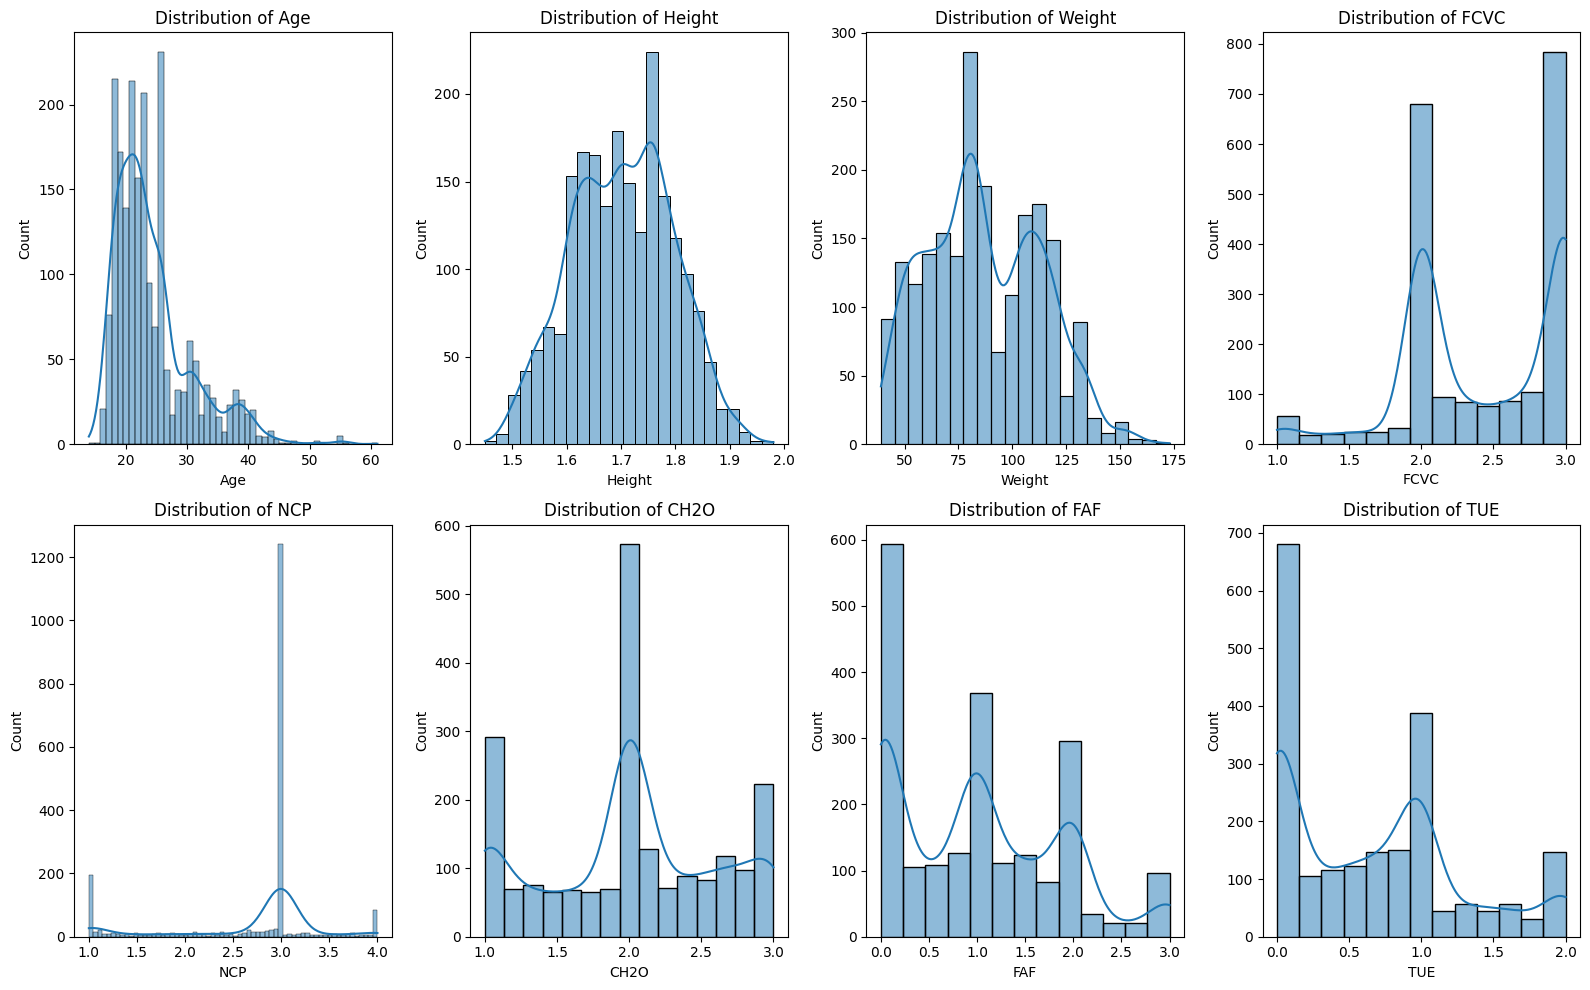

In [24]:
numeric_cols = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]

plt.figure(figsize=(16, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 4, i + 1)
    sns.histplot(x=col, data=df, kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

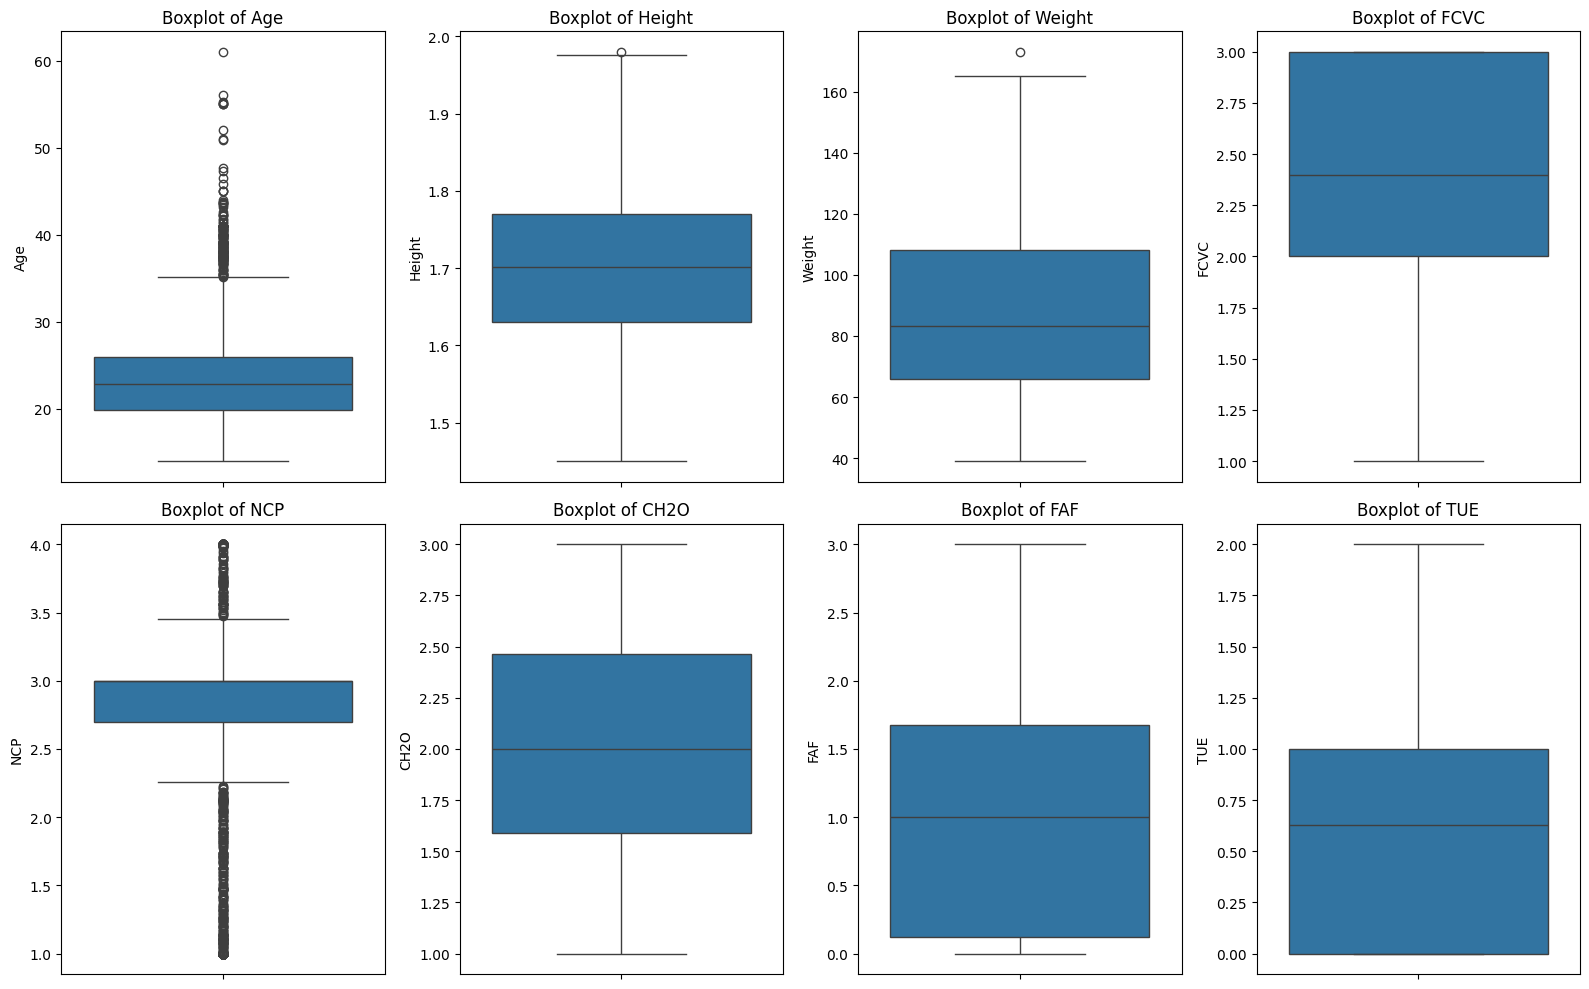

In [15]:
plt.figure(figsize=(16, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(y=col, data=df)
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

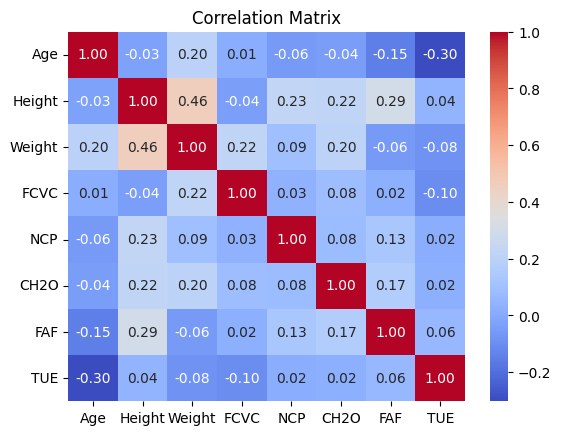

In [25]:
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

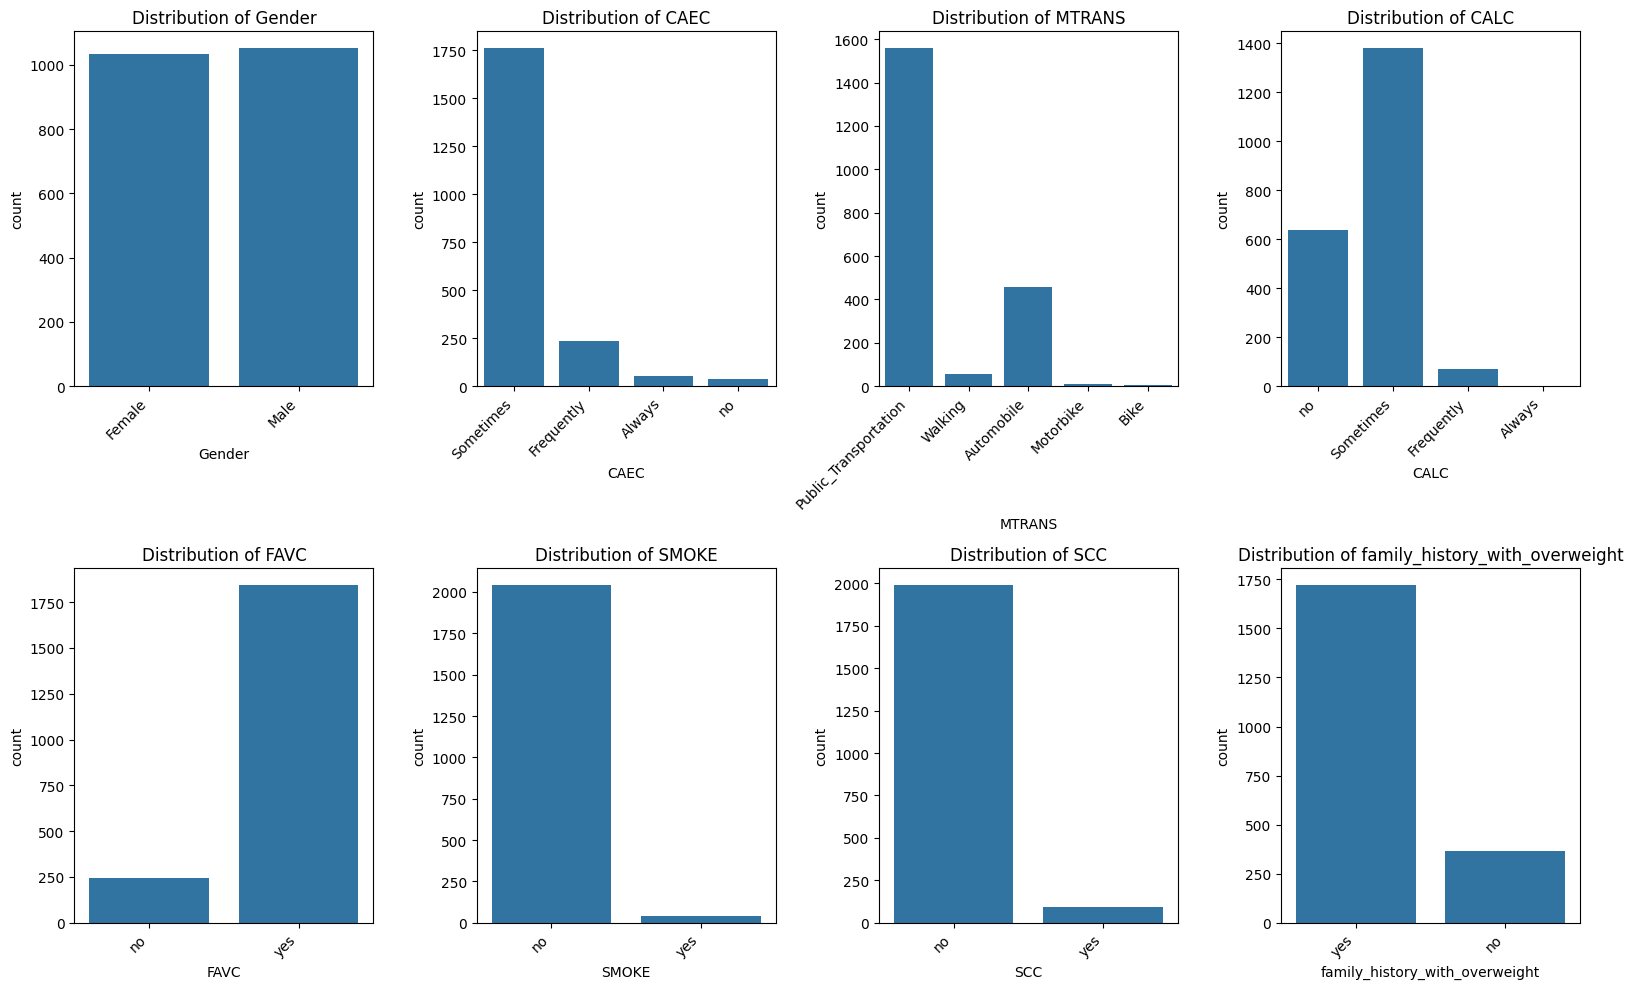

In [26]:
cat_cols = ["Gender", "CAEC", "MTRANS", "CALC", "FAVC", "SMOKE", "SCC", "family_history_with_overweight"]

plt.figure(figsize=(16, 10))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 4, i + 1)
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

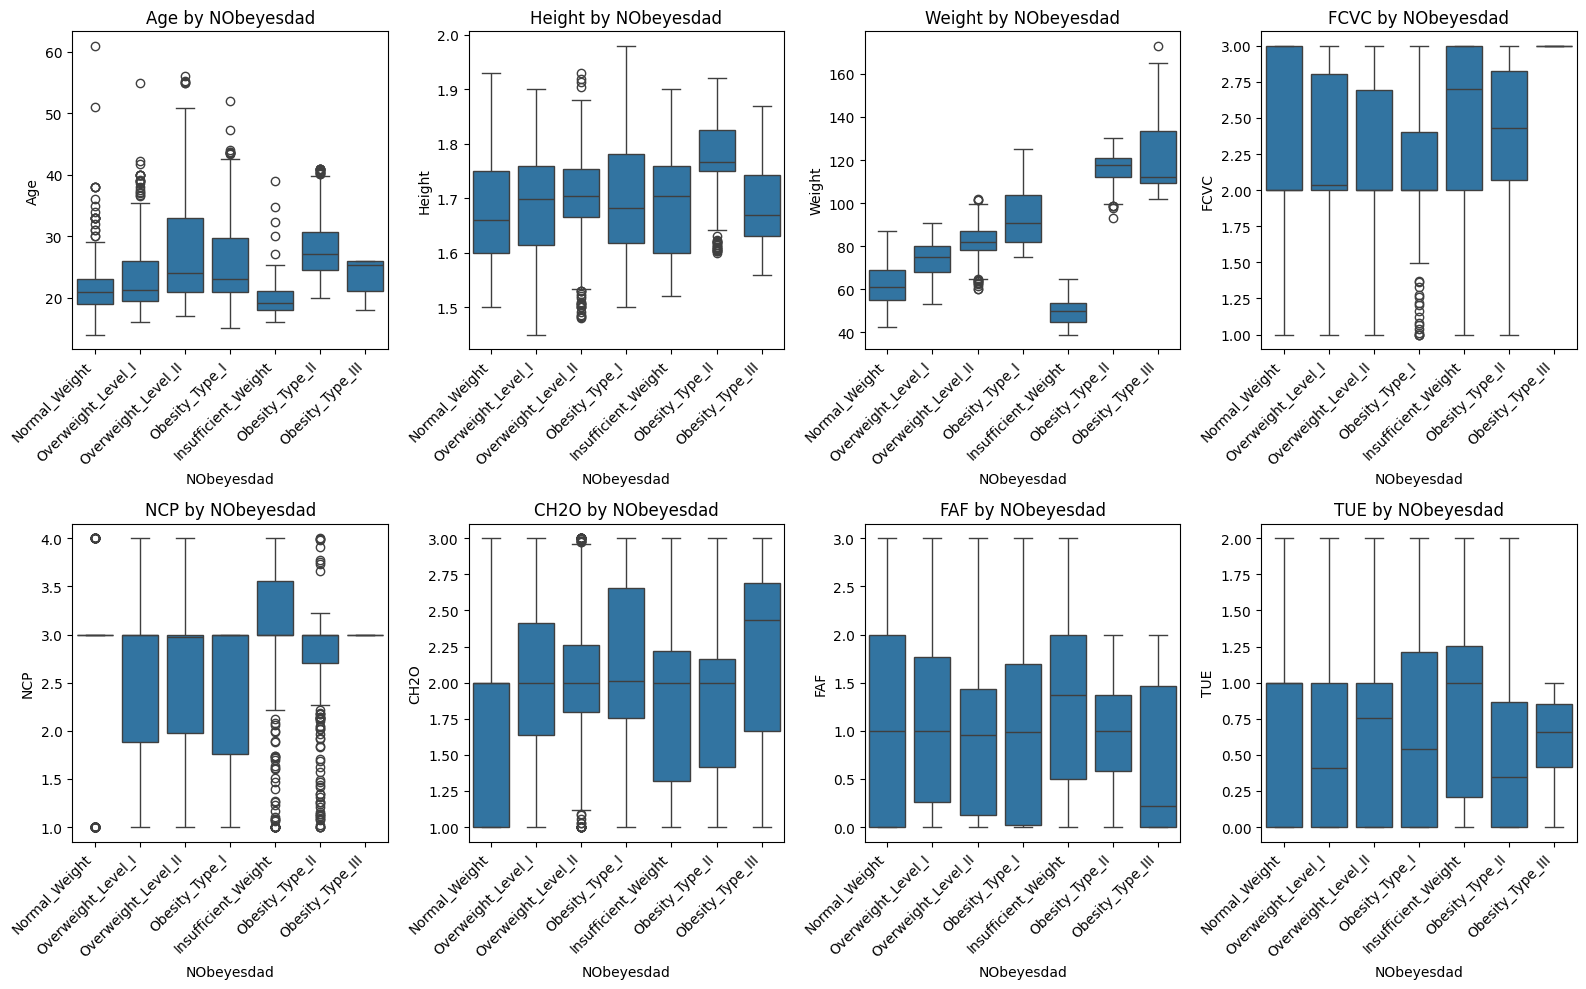

In [18]:
plt.figure(figsize=(16, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(x="NObeyesdad", y=col, data=df)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"{col} by NObeyesdad")

plt.tight_layout()
plt.show()

In [27]:
# The last plot shows that there are some outliers in the numeric columns, especially in Age, Height, Weight, and FAF.
# We will need to handle these outliers before training our model.

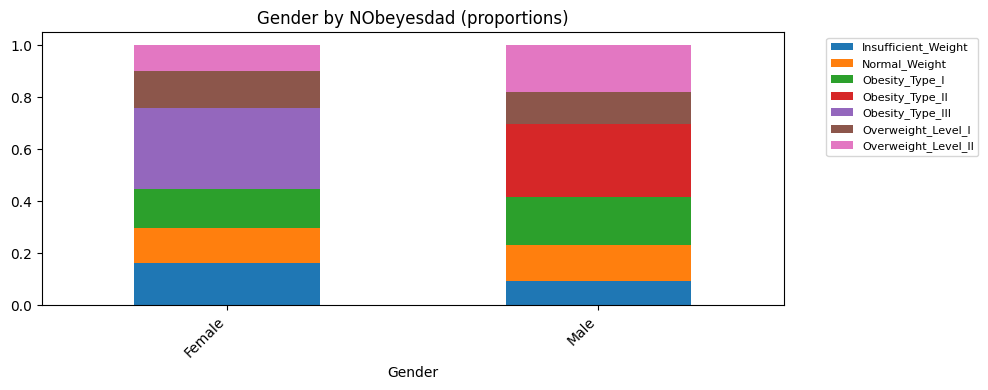

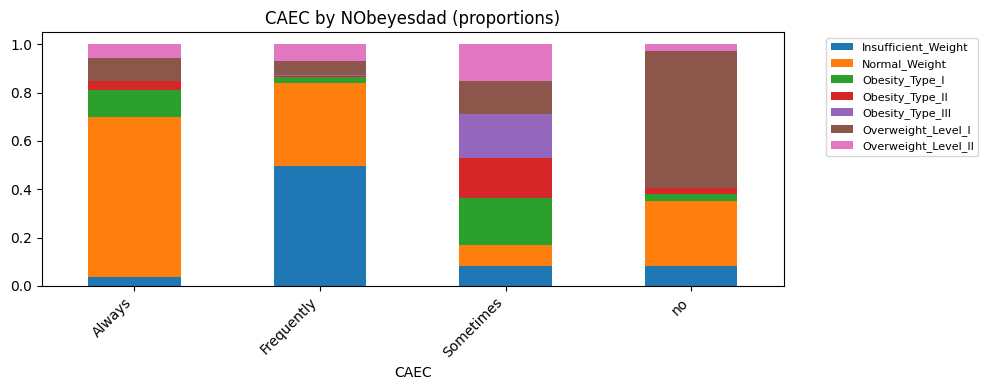

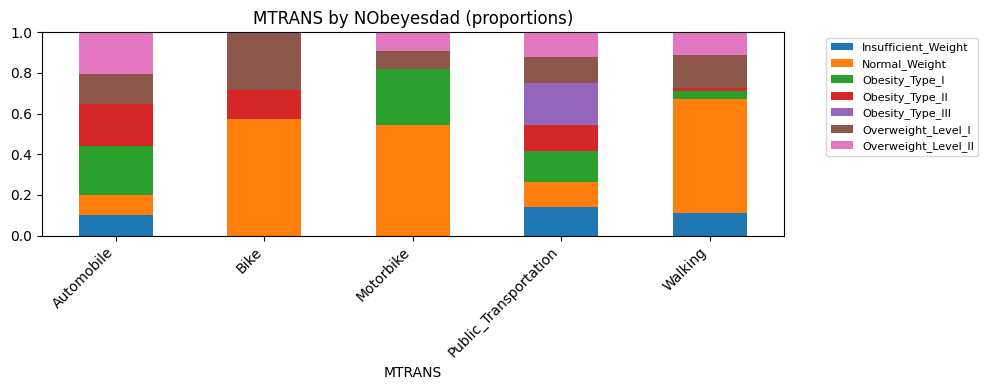

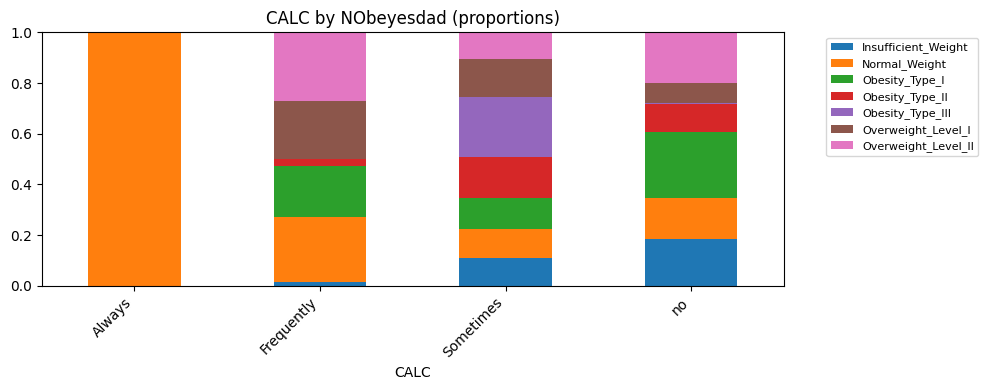

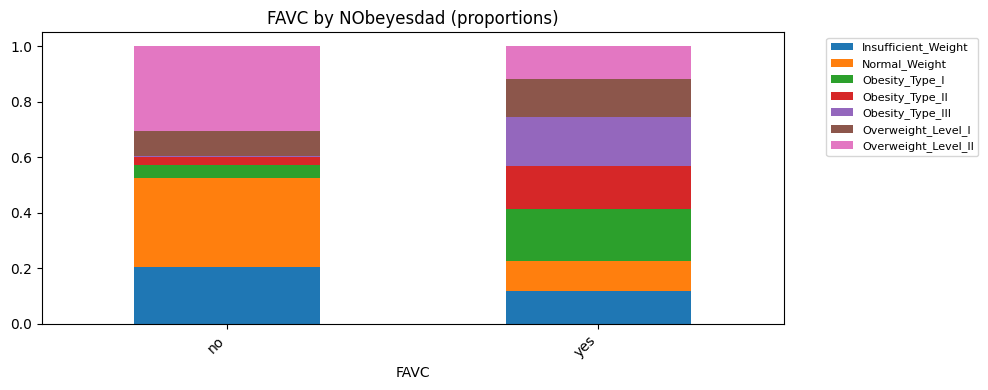

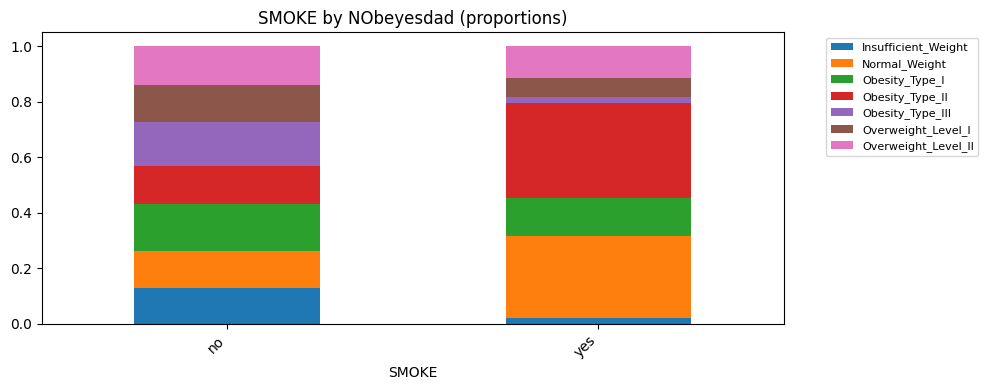

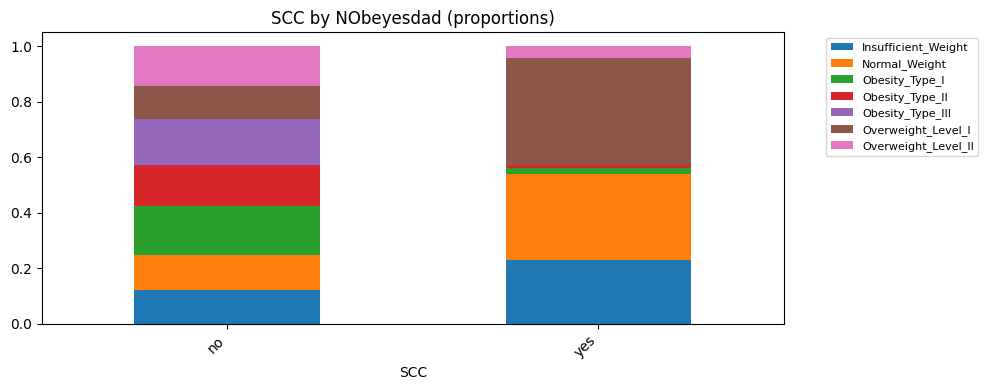

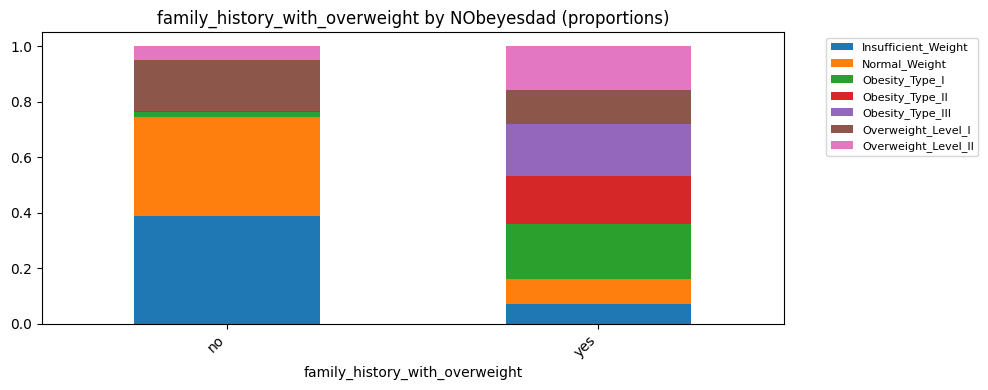

In [28]:
for col in cat_cols:
    ct = pd.crosstab(df[col], df["NObeyesdad"], normalize="index")
    ct.plot(kind="bar", stacked=True, figsize=(10, 4))
    plt.title(f"{col} by NObeyesdad (proportions)")
    plt.xticks(rotation=45, ha="right")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

In [30]:
#Here is the interpretation for each variable:
#Gender
#Women show higher concentration of Obesity_Type_III (31%), while men concentrate more in Obesity_Type_II (28%). 
#A clear gender-based split in severe obesity types.
#CAEC (snacking between meals)
#Surprisingly, people who snack Always tend toward Normal Weight (66%). Those who snack Sometimes spread more toward obesity classes.
#People who never snack (no) are mostly Overweight_Level_I (57%). More snacking does not imply more obesity here.
#MTRANS (transportation)
#Car users show the strongest association with obesity (24% Type I, 21% Type II). Walking and cycling concentrate in Normal or Insufficient Weight.
#This aligns with expected sedentary behavior patterns.
#CALC (alcohol consumption)
#Always maps 100% to Normal Weight, but the sample is very small — not reliable. No strong signal overall. Low predictive value expected.
#FAVC (high-calorie food intake)
#Clear pattern: yes accumulates across obesity classes (18% Type I, 16% Type II, 18% Type III). no concentrates in Normal Weight (32%). Strong predictor.
#SMOKE
#Very small yes category and no consistent pattern across obesity classes. Low predictive value expected.
#SCC (monitors calorie intake)
#People who monitor calories (yes) concentrate in Normal Weight (31%) and Insufficient Weight (23%).
#Calorie awareness is clearly associated with lower obesity levels.
#family_history_with_overweight
#Strongest categorical predictor. No family history: 39% Insufficient + 36% Normal Weight.
#With family history: 20% Type I + 17% Type II + 19% Type III. Highly recommended to include in the KNN model.

#Key takeaway: The most predictive categorical variables are family_history_with_overweight, FAVC, SCC and MTRANS. SMOKE and CALC show weak signal and may have limited impact on model performance.